In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
import random
from datetime import datetime, timedelta
from urllib.parse import urlparse
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

os.makedirs('../reports', exist_ok=True)
os.makedirs('../models',  exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

# Load cleaned dataset saved by Phase 1
# This already has duplicates removed and missing ClassLabel dropped
# and labels correctly mapped (0.0 = Phishing, 1.0 = Legitimate)
df = pd.read_csv('../data/raw/url_features_cleaned.csv')
print(f"Loaded cleaned dataset: {df.shape}")
print(f"\nClass distribution:")
print(df['ClassLabel'].value_counts())
print(f"\nMissing values: {df.isnull().sum().sum()}")

Loaded cleaned dataset: (100873, 18)

Class distribution:
ClassLabel
1.0    63492
0.0    37380
Name: count, dtype: int64

Missing values: 1


In [10]:
# Load cleaned dataset saved by Phase 1
df = pd.read_csv('../data/raw/url_features_cleaned.csv')

# Drop any remaining NaN in ClassLabel — map() can reintroduce NaN
df = df.dropna(subset=['ClassLabel'])

print(f"Loaded cleaned dataset: {df.shape}")
print(f"\nClass distribution:")
print(df['ClassLabel'].value_counts())
print(f"\nMissing values in ClassLabel: {df['ClassLabel'].isnull().sum()}")

Loaded cleaned dataset: (100872, 18)

Class distribution:
ClassLabel
1.0    63492
0.0    37380
Name: count, dtype: int64

Missing values in ClassLabel: 0


In [11]:
from urllib.parse import urlparse

def extract_domain(url):
    parsed = urlparse(url)
    return parsed.netloc

df['domain'] = df['URL'].apply(extract_domain)

# Check a few examples
print(df[['URL', 'domain']].head())

                                               URL  \
0  https://keraekken-loagginnusa.godaddysites.com/   
1         https://metamsk01lgiix.godaddysites.com/   
2                          http://myglobaltech.in/   
3                   http://djtool-for-spotify.com/   
4  https://scearmcoommunnlty.com/invent/freind/get   

                                   domain  
0  keraekken-loagginnusa.godaddysites.com  
1         metamsk01lgiix.godaddysites.com  
2                         myglobaltech.in  
3                  djtool-for-spotify.com  
4                   scearmcoommunnlty.com  


In [12]:
# Identify feature columns
feature_cols = [col for col in df.columns 
                if col not in ['ClassLabel', 'URL', 'domain']]
print("Feature columns:", feature_cols)
print(f"Total base features: {len(feature_cols)}")

# Create feature matrix X and target vector y
X = df[feature_cols]
y = df['ClassLabel']

# Save feature column names — critical for all downstream phases
np.save('../data/processed/feature_cols.npy', feature_cols)
print(f"\nfeature_cols.npy saved with {len(feature_cols)} features")

Feature columns: ['url_length', 'has_ip_address', 'dot_count', 'https_flag', 'url_entropy', 'token_count', 'subdomain_count', 'query_param_count', 'tld_length', 'path_length', 'has_hyphen_in_domain', 'number_of_digits', 'tld_popularity', 'suspicious_file_extension', 'domain_name_length', 'percentage_numeric_chars']
Total base features: 16

feature_cols.npy saved with 16 features


In [13]:
# Split FIRST then clip then scale — correct order
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape}  Test: {X_test.shape}")

# IQR clipping using training data bounds only
Q1  = X_train.quantile(0.25)
Q3  = X_train.quantile(0.75)
IQR = Q3 - Q1

X_train_clipped = X_train.clip(
    lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR, axis=1
)
X_test_clipped = X_test.clip(
    lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR, axis=1
)

# Save IQR bounds for dashboard use later
iqr_bounds = pd.DataFrame({'Q1': Q1, 'Q3': Q3, 'IQR': IQR})
iqr_bounds.to_csv('../data/processed/iqr_bounds.csv')
print("IQR bounds saved")

# Scale using clipped data — fit on training only
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clipped)
X_test_scaled  = scaler.transform(X_test_clipped)

print(f"\nScaler fitted on {scaler.n_features_in_} features")
print(f"Train scaled shape: {X_train_scaled.shape}")
print(f"Test scaled shape:  {X_test_scaled.shape}")

# Save everything
joblib.dump(scaler, '../models/scaler.pkl')
np.save('../data/processed/X_train_scaled.npy', X_train_scaled)
np.save('../data/processed/X_test_scaled.npy',  X_test_scaled)
np.save('../data/processed/y_train.npy',         y_train.values)
np.save('../data/processed/y_test.npy',          y_test.values)

print("\nAll files saved:")
print(f"  scaler.pkl          — {scaler.n_features_in_} features")
print(f"  X_train_scaled.npy  — {X_train_scaled.shape}")
print(f"  X_test_scaled.npy   — {X_test_scaled.shape}")

Train: (80697, 16)  Test: (20175, 16)
IQR bounds saved

Scaler fitted on 16 features
Train scaled shape: (80697, 16)
Test scaled shape:  (20175, 16)

All files saved:
  scaler.pkl          — 16 features
  X_train_scaled.npy  — (80697, 16)
  X_test_scaled.npy   — (20175, 16)


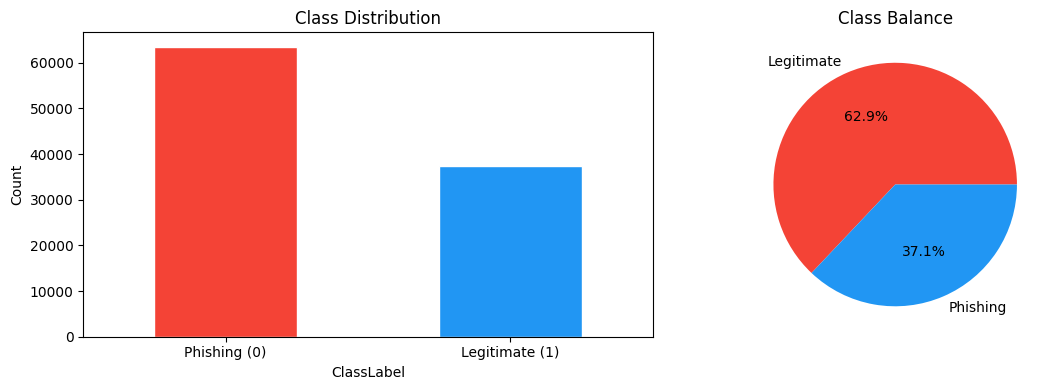

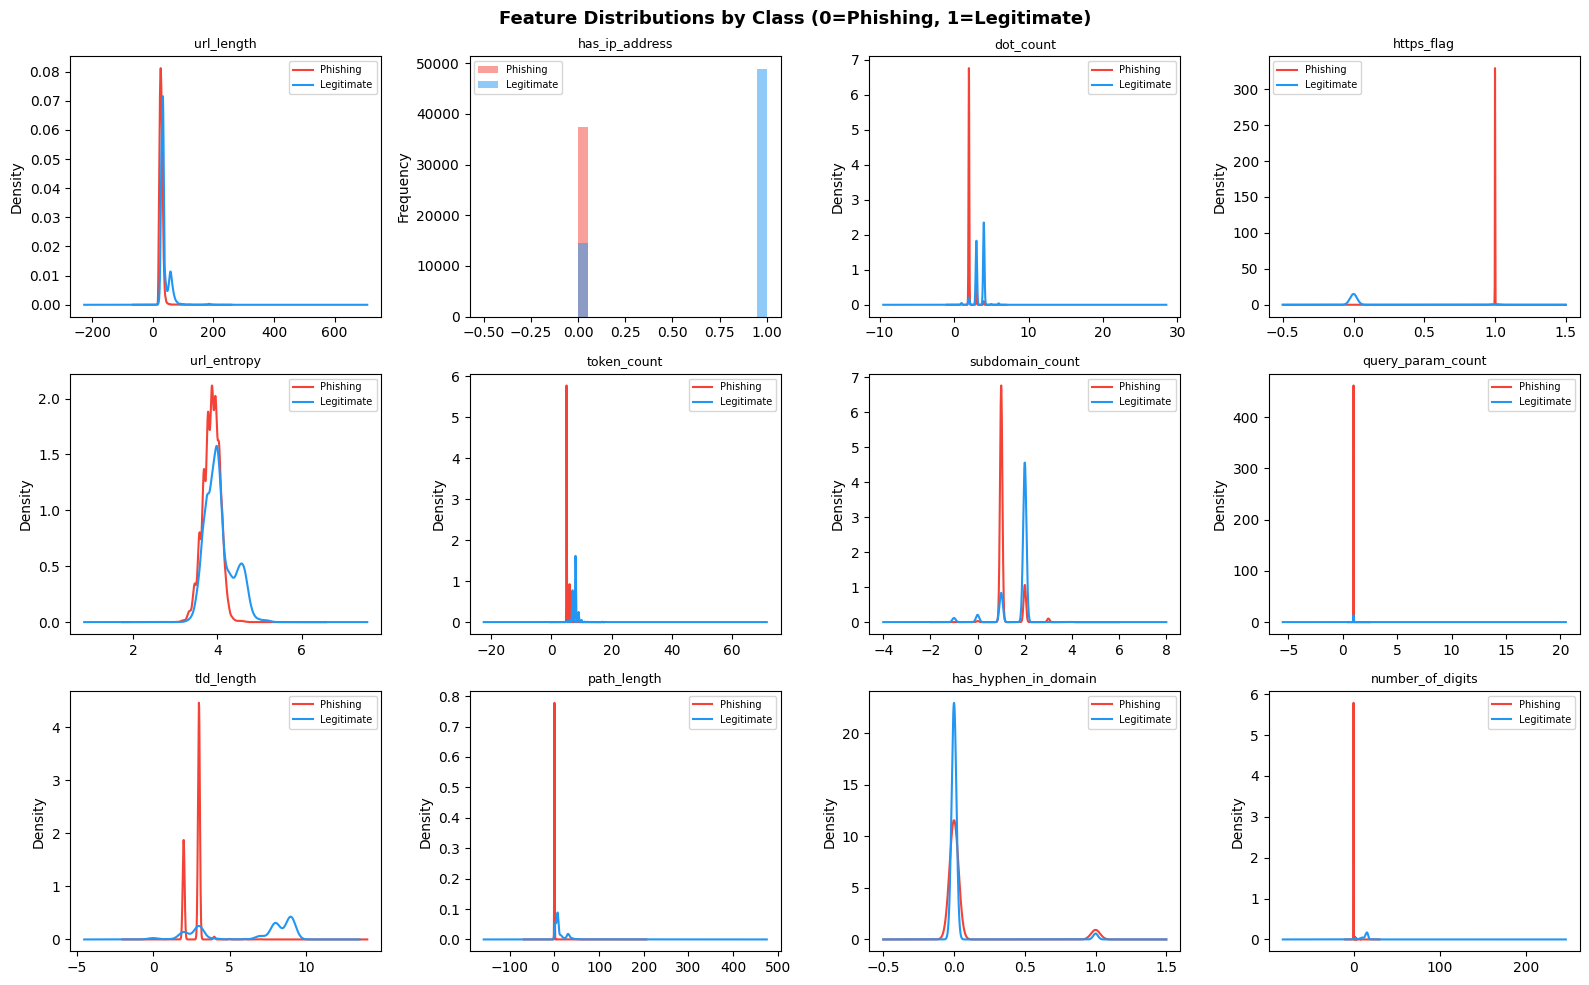

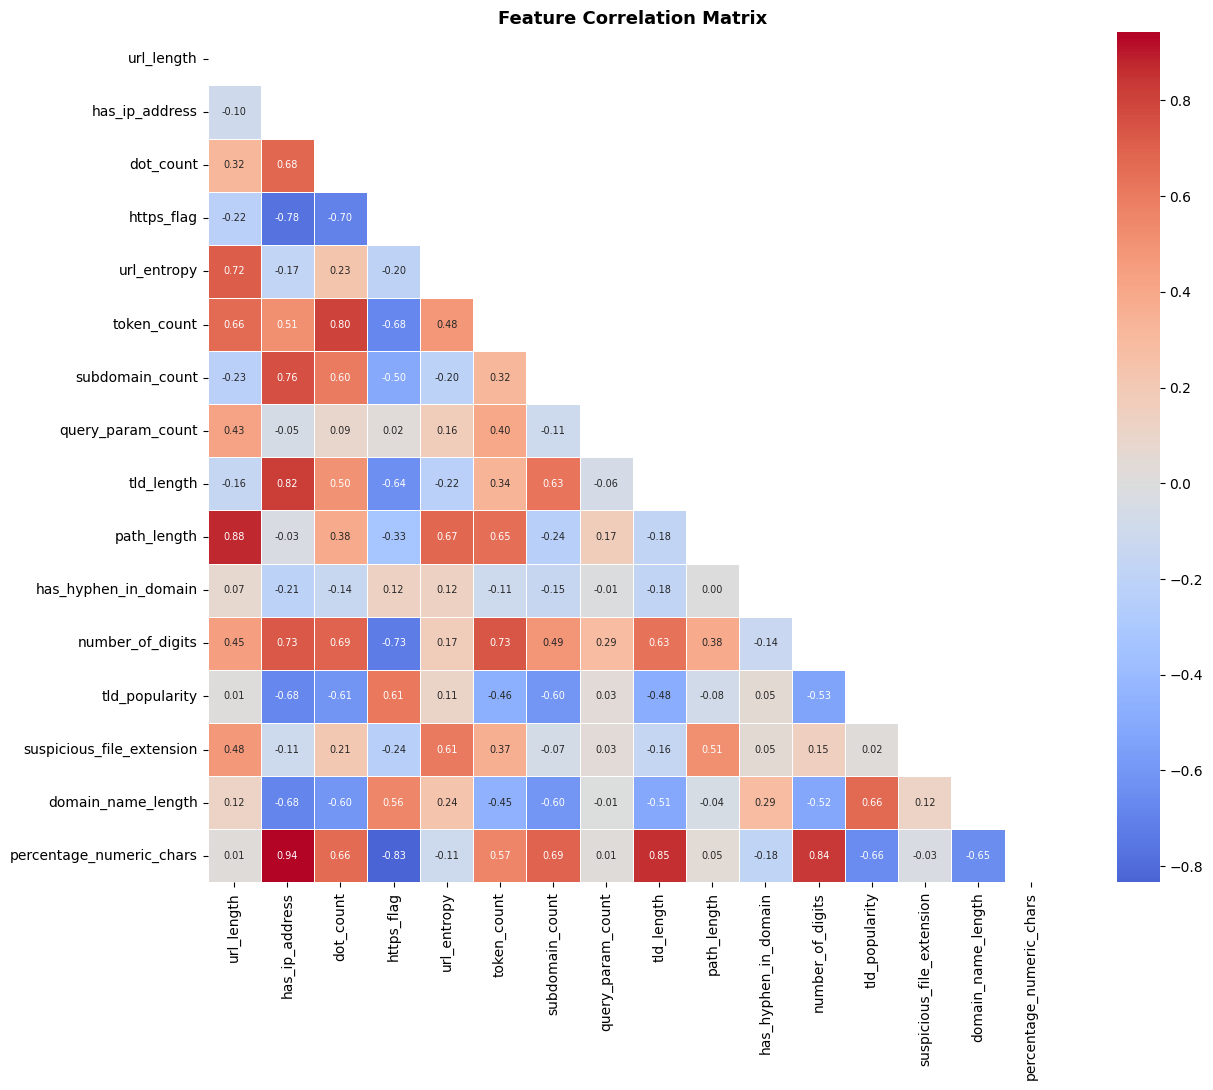

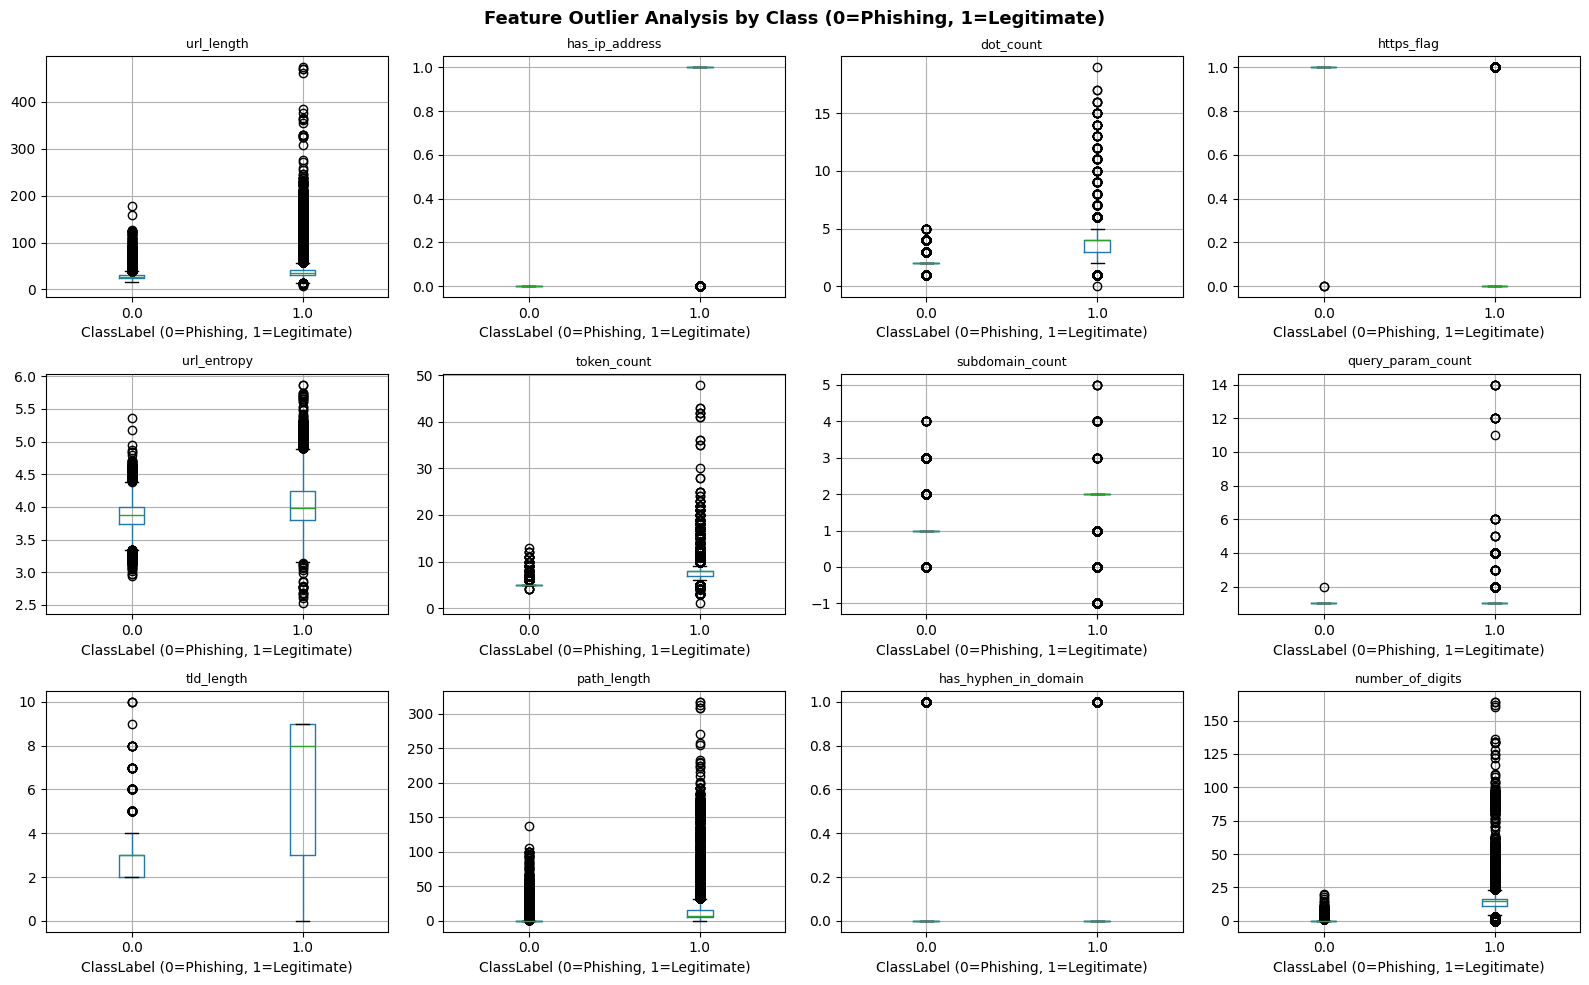

All 4 EDA plots saved to ../reports/
Label convention: 0.0 = Phishing  |  1.0 = Legitimate


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('../reports', exist_ok=True)

feature_cols = [col for col in df.columns
                if col not in ['ClassLabel', 'URL', 'domain']]

# ── Plot 1: Class Distribution ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['ClassLabel'].value_counts().plot.bar(
    ax=axes[0], color=['#F44336', '#2196F3'], edgecolor='white'
)
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['Phishing (0)', 'Legitimate (1)'], rotation=0)
axes[0].set_ylabel('Count')

counts = df['ClassLabel'].value_counts(normalize=True)
counts.index = counts.index.map({0.0: 'Phishing', 1.0: 'Legitimate'})
counts.plot.pie(
    ax=axes[1], autopct='%1.1f%%',
    colors=['#F44336', '#2196F3']
)
axes[1].set_title('Class Balance')

plt.tight_layout()
plt.savefig('../reports/class_distribution.png', dpi=150)
plt.show()

# ── Plot 2: Feature Distributions by Class ───────────────────────
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols[:12]):
    try:
        df[df['ClassLabel']==0.0][col].plot.kde(
            ax=axes[i], label='Phishing',   color='#F44336'
        )
        df[df['ClassLabel']==1.0][col].plot.kde(
            ax=axes[i], label='Legitimate', color='#2196F3'
        )
    except Exception:
        df[df['ClassLabel']==0.0][col].plot.hist(
            ax=axes[i], alpha=0.5, label='Phishing',
            color='#F44336', bins=20
        )
        df[df['ClassLabel']==1.0][col].plot.hist(
            ax=axes[i], alpha=0.5, label='Legitimate',
            color='#2196F3', bins=20
        )
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)

plt.suptitle('Feature Distributions by Class (0=Phishing, 1=Legitimate)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/feature_distributions.png', dpi=150)
plt.show()

# ── Plot 3: Correlation Heatmap ───────────────────────────────────
plt.figure(figsize=(14, 11))
corr = df[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, cmap='coolwarm', center=0,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    square=True, linewidths=0.5
)
plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png', dpi=150)
plt.show()

# ── Plot 4: Boxplots ──────────────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols[:12]):
    df.boxplot(column=col, by='ClassLabel', ax=axes[i])
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('ClassLabel (0=Phishing, 1=Legitimate)')

plt.suptitle('Feature Outlier Analysis by Class (0=Phishing, 1=Legitimate)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/feature_boxplots.png', dpi=150)
plt.show()

print("All 4 EDA plots saved to ../reports/")
print("Label convention: 0.0 = Phishing  |  1.0 = Legitimate")

In [15]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
print(pd.Series(y_train).value_counts())
print("  0.0 = Phishing  |  1.0 = Legitimate")

sm = SMOTE(random_state=42, k_neighbors=5)
X_train_balanced, y_train_balanced = sm.fit_resample(
    X_train_scaled, y_train
)

print("\nAfter SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

np.save('../data/processed/X_train_balanced.npy', X_train_balanced)
np.save('../data/processed/y_train_balanced.npy', y_train_balanced)
print("SMOTE balanced arrays saved")

Before SMOTE:
ClassLabel
1.0    50793
0.0    29904
Name: count, dtype: int64
  0.0 = Phishing  |  1.0 = Legitimate

After SMOTE:
ClassLabel
1.0    50793
0.0    50793
Name: count, dtype: int64
SMOTE balanced arrays saved


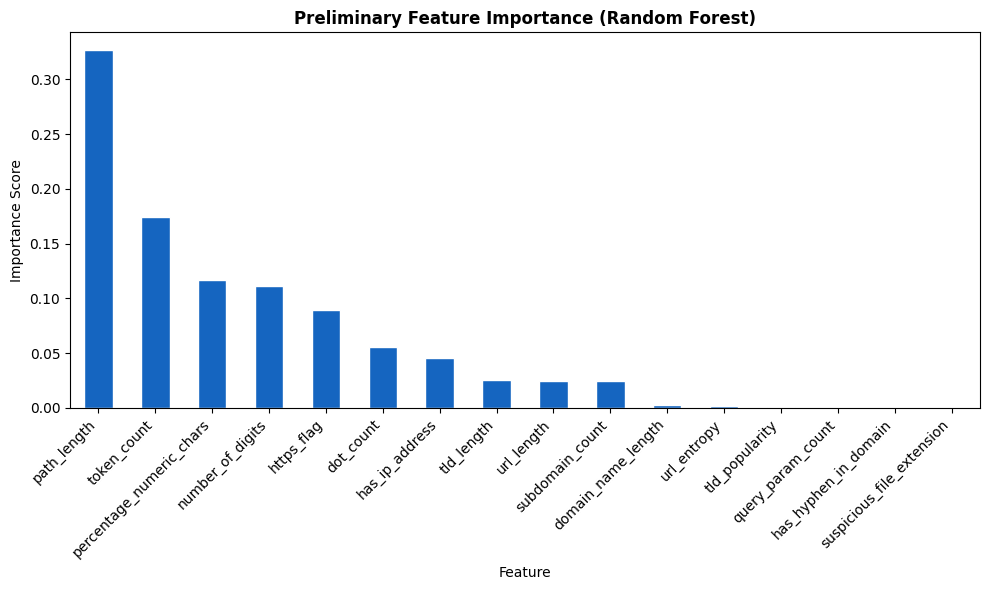


Top 5 most important features:
path_length                 0.326502
token_count                 0.173830
percentage_numeric_chars    0.117047
number_of_digits            0.111351
https_flag                  0.089218
dtype: float64

Bottom 5 least important features:
url_entropy                  0.002006
tld_popularity               0.001012
query_param_count            0.000000
has_hyphen_in_domain         0.000000
suspicious_file_extension    0.000000
dtype: float64


In [16]:
from sklearn.ensemble import RandomForestClassifier

# Quick RF just for feature importance — not the final model
rf_preview = RandomForestClassifier(
    n_estimators=50, random_state=42, n_jobs=-1
)
rf_preview.fit(X_train_scaled, y_train)

importances = pd.Series(
    rf_preview.feature_importances_, index=feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot.bar(color='#1565C0', edgecolor='white')
plt.title('Preliminary Feature Importance (Random Forest)', fontweight='bold')
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/feature_importance_preview.png', dpi=150)
plt.show()

print("\nTop 5 most important features:")
print(importances.head())
print("\nBottom 5 least important features:")
print(importances.tail())

In [18]:
import random
from datetime import datetime, timedelta
import os

def generate_apache_log(num_lines=5000, 
                         output_file='../data/logs/synthetic.log'):
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    
    normal_ips  = [f'192.168.1.{i}' for i in range(1, 51)]
    urls        = ['/index.html', '/home', '/about', 
                   '/contact', '/products', '/login']
    status_ok   = [200, 200, 200, 302]
    
    with open(output_file, 'w') as f:
        start = datetime(2026, 3, 1)
        for _ in range(num_lines):
            ip     = random.choice(normal_ips)
            ts     = (start + timedelta(
                        seconds=random.randint(0, 86400)
                      )).strftime('%d/%b/%Y:%H:%M:%S +0000')
            method = random.choice(['GET', 'POST'])
            url    = random.choice(urls)
            status = random.choice(status_ok)
            size   = random.randint(500, 8000)
            f.write(
                f'{ip} - - [{ts}] '
                f'"{method} {url} HTTP/1.1" {status} {size}\n'
            )

def inject_anomalies(output_file, num_anomalies=300):
    """
    Three distinct anomaly patterns:
    1. Brute-force login burst from single IP
    2. Directory traversal / admin scanning
    3. Rapid sequential requests (bot-like)
    """
    attack_ips   = ['10.0.0.99', '185.220.101.45', '172.16.5.200']
    attack_urls  = ['/wp-admin', '/admin/login', '/admin/passwd',
                    '/.env', '/config.php', '/secure/bank',
                    '/login', '/admin']
    
    with open(output_file, 'a') as f:
        # Pattern 1: Brute-force — same IP, rapid login attempts
        start = datetime(2026, 3, 1, 2, 0, 0)  # 2am
        for i in range(150):
            ts = (start + timedelta(seconds=i * 0.8)
                  ).strftime('%d/%b/%Y:%H:%M:%S +0000')
            f.write(
                f'10.0.0.99 - - [{ts}] '
                f'"POST /login HTTP/1.1" 403 210\n'
            )
        
        # Pattern 2: Admin scanning — hitting many sensitive endpoints
        start2 = datetime(2026, 3, 1, 3, 15, 0)
        for i in range(100):
            url = attack_urls[i % len(attack_urls)]
            ts  = (start2 + timedelta(seconds=i * 2)
                   ).strftime('%d/%b/%Y:%H:%M:%S +0000')
            f.write(
                f'185.220.101.45 - - [{ts}] '
                f'"GET {url} HTTP/1.1" 404 180\n'
            )
        
        # Pattern 3: High volume bot traffic
        start3 = datetime(2026, 3, 1, 4, 0, 0)
        for i in range(50):
            ts = (start3 + timedelta(seconds=i * 0.3)
                  ).strftime('%d/%b/%Y:%H:%M:%S +0000')
            f.write(
                f'172.16.5.200 - - [{ts}] '
                f'"GET /index.html HTTP/1.1" 200 4500\n'
            )

generate_apache_log(5000)
inject_anomalies('../data/logs/synthetic.log', 300)
print("Generated 5,000 normal + 300 anomaly log lines")
print(f"Total lines: 5300")

Generated 5,000 normal + 300 anomaly log lines
Total lines: 5300


Total log entries parsed: 5300
             ip           timestamp method          url  status  size
0  192.168.1.42 2026-03-01 22:48:01   POST     /contact     200  1762
1  192.168.1.27 2026-03-01 16:43:48    GET       /about     200  6234
2  192.168.1.41 2026-03-01 18:24:47    GET  /index.html     200  1576
3  192.168.1.32 2026-03-01 16:30:00    GET    /products     200   543
4  192.168.1.22 2026-03-01 00:23:24   POST     /contact     302  6772

Log feature matrix shape: (53, 7)

Top 10 IPs by request count:
              ip  request_count  unique_urls  error_rate     avg_size  \
0      10.0.0.99            150            1         1.0   210.000000   
52   192.168.1.9            131            6         0.0  4161.045802   
19  192.168.1.24            118            6         0.0  4362.813559   
27  192.168.1.31            114            6         0.0  4415.122807   
39  192.168.1.42            113            6         0.0  4556.415929   
44  192.168.1.47            112            6  

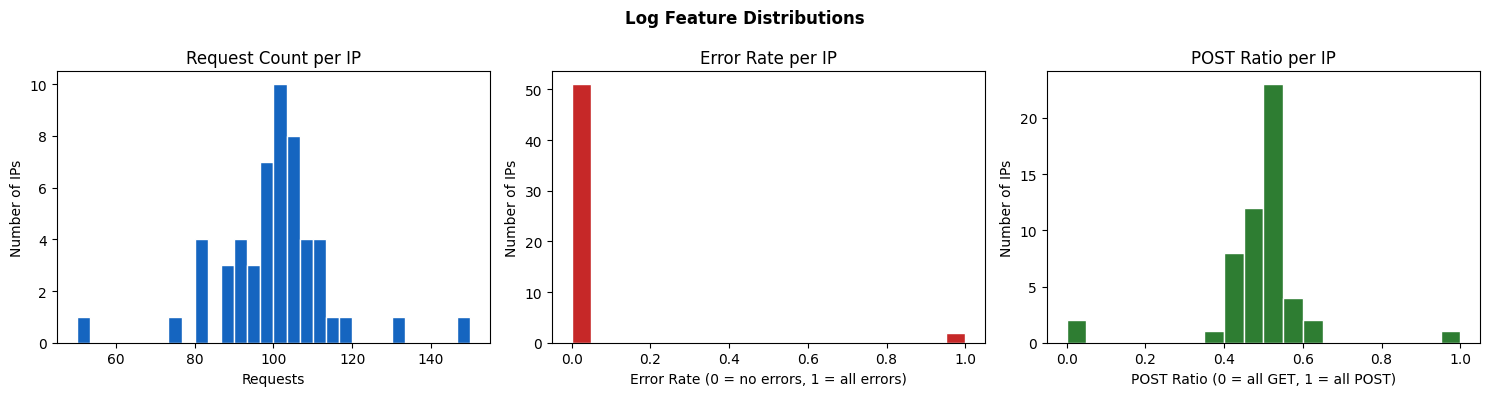


Suspected anomalous IPs found: 4
                ip  request_count  error_rate  post_ratio  \
0        10.0.0.99            150         1.0    1.000000   
2   185.220.101.45            100         1.0    0.000000   
19    192.168.1.24            118         0.0    0.483051   
52     192.168.1.9            131         0.0    0.503817   

                                       anomaly_reason  
0   high_request_count | high_error_rate | high_po...  
2                                     high_error_rate  
19                                 high_request_count  
52                                 high_request_count  

Suspected anomalies saved to ../data/processed/suspected_anomalies.csv


In [19]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs('../reports', exist_ok=True)

# ── Step 1: Parse log file ─────────────────────────────────────────
log_pattern = re.compile(
    r'(\S+) - - \[(.*?)\] "(\S+) (\S+) \S+" (\d+) (\d+)'
)

records = []
with open('../data/logs/synthetic.log') as f:
    for line in f:
        m = log_pattern.match(line)
        if m:
            ip, ts, method, url, status, size = m.groups()
            records.append({
                'ip'       : ip,
                'timestamp': ts,
                'method'   : method,
                'url'      : url,
                'status'   : int(status),
                'size'     : int(size)
            })

log_df = pd.DataFrame(records)
log_df['timestamp'] = pd.to_datetime(
    log_df['timestamp'], format='%d/%b/%Y:%H:%M:%S +0000'
)

print(f"Total log entries parsed: {len(log_df)}")
print(log_df.head())

# ── Step 2: Build per-IP feature matrix ───────────────────────────
log_features = log_df.groupby('ip').agg(
    request_count     = ('url',    'count'),
    unique_urls       = ('url',    'nunique'),
    error_rate        = ('status', lambda x: (x >= 400).mean()),
    avg_size          = ('size',   'mean'),
    post_ratio        = ('method', lambda x: (x == 'POST').mean()),
    unique_url_ratio  = ('url',    lambda x: x.nunique() / len(x))
).reset_index()

print(f"\nLog feature matrix shape: {log_features.shape}")
print("\nTop 10 IPs by request count:")
print(log_features.sort_values('request_count', ascending=False).head(10))

log_features.to_csv('../data/processed/log_features.csv', index=False)
print("\nLog features saved to ../data/processed/log_features.csv")

# ── Step 3: Visualize ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

log_features['request_count'].plot.hist(
    ax=axes[0], bins=30, color='#1565C0', edgecolor='white'
)
axes[0].set_title('Request Count per IP')
axes[0].set_xlabel('Requests')
axes[0].set_ylabel('Number of IPs')

log_features['error_rate'].plot.hist(
    ax=axes[1], bins=20, color='#C62828', edgecolor='white'
)
axes[1].set_title('Error Rate per IP')
axes[1].set_xlabel('Error Rate (0 = no errors, 1 = all errors)')
axes[1].set_ylabel('Number of IPs')

log_features['post_ratio'].plot.hist(
    ax=axes[2], bins=20, color='#2E7D32', edgecolor='white'
)
axes[2].set_title('POST Ratio per IP')
axes[2].set_xlabel('POST Ratio (0 = all GET, 1 = all POST)')
axes[2].set_ylabel('Number of IPs')

plt.suptitle('Log Feature Distributions', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/log_feature_distributions.png', dpi=150)
plt.show()

# ── Step 4: Flag suspected anomalies for review ───────────────────
# High request count + high error rate + high POST ratio = suspicious
suspected = log_features[
    (log_features['request_count'] > log_features['request_count'].quantile(0.95)) |
    (log_features['error_rate']    > 0.7) |
    (log_features['post_ratio']    > 0.8)
].copy()

suspected['anomaly_reason'] = ''

suspected.loc[
    log_features['request_count'] > log_features['request_count'].quantile(0.95),
    'anomaly_reason'
] += 'high_request_count | '

suspected.loc[
    log_features['error_rate'] > 0.7,
    'anomaly_reason'
] += 'high_error_rate | '

suspected.loc[
    log_features['post_ratio'] > 0.8,
    'anomaly_reason'
] += 'high_post_ratio | '

suspected['anomaly_reason'] = suspected['anomaly_reason'].str.rstrip(' | ')

print(f"\nSuspected anomalous IPs found: {len(suspected)}")
print(suspected[['ip', 'request_count', 'error_rate', 
                  'post_ratio', 'anomaly_reason']])

suspected.to_csv('../data/processed/suspected_anomalies.csv', index=False)
print("\nSuspected anomalies saved to ../data/processed/suspected_anomalies.csv")

In [20]:
import json

phase2_report = {
    'cleaned_rows'           : int(len(df)),
    'num_base_features'      : len(feature_cols),
    'num_graph_features'     : 4,
    'num_total_features'     : len(feature_cols) + 4,
    'features_used'          : list(feature_cols),
    'train_size'             : int(X_train_scaled.shape[0]),
    'test_size'              : int(X_test_scaled.shape[0]),
    'smote_applied'          : True,
    'train_size_after_smote' : int(X_train_balanced.shape[0]),
    'scaler_features'        : int(scaler.n_features_in_),
    'iqr_clipping_applied'   : True,
    'label_convention'       : '0.0 = Phishing, 1.0 = Legitimate',
    'log_entries_total'      : 5300,
    'log_normal_lines'       : 5000,
    'log_anomaly_lines'      : 300,
    'outputs': {
        'X_train_scaled'     : '../data/processed/X_train_scaled.npy',
        'X_test_scaled'      : '../data/processed/X_test_scaled.npy',
        'X_train_balanced'   : '../data/processed/X_train_balanced.npy',
        'y_train'            : '../data/processed/y_train.npy',
        'y_test'             : '../data/processed/y_test.npy',
        'scaler'             : '../models/scaler.pkl',
        'feature_cols'       : '../data/processed/feature_cols.npy',
        'iqr_bounds'         : '../data/processed/iqr_bounds.csv',
        'log_features'       : '../data/processed/log_features.csv',
    }
}

with open('../reports/phase2_report.json', 'w') as f:
    json.dump(phase2_report, f, indent=2)

print("Phase 2 report saved")
print(json.dumps(phase2_report, indent=2))

Phase 2 report saved
{
  "cleaned_rows": 100872,
  "num_base_features": 16,
  "num_graph_features": 4,
  "num_total_features": 20,
  "features_used": [
    "url_length",
    "has_ip_address",
    "dot_count",
    "https_flag",
    "url_entropy",
    "token_count",
    "subdomain_count",
    "query_param_count",
    "tld_length",
    "path_length",
    "has_hyphen_in_domain",
    "number_of_digits",
    "tld_popularity",
    "suspicious_file_extension",
    "domain_name_length",
    "percentage_numeric_chars"
  ],
  "train_size": 80697,
  "test_size": 20175,
  "smote_applied": true,
  "train_size_after_smote": 101586,
  "scaler_features": 16,
  "iqr_clipping_applied": true,
  "label_convention": "0.0 = Phishing, 1.0 = Legitimate",
  "log_entries_total": 5300,
  "log_normal_lines": 5000,
  "log_anomaly_lines": 300,
  "outputs": {
    "X_train_scaled": "../data/processed/X_train_scaled.npy",
    "X_test_scaled": "../data/processed/X_test_scaled.npy",
    "X_train_balanced": "../data/proce